# 1 Creating and Manipulating Arrays

In [5]:
import numpy as np
import matplotlib.pyplot as plt

## 1.1 Create two 2D arrays representing coordinates x, y on the cartesian plan

In [6]:
x_val = np.linspace(-2, 2, 100)
y_val = np.linspace(-2, 2, 100)
x, y = np.meshgrid(x_val, y_val)

## 1.2 Visualize each 2D array using pcolormesh

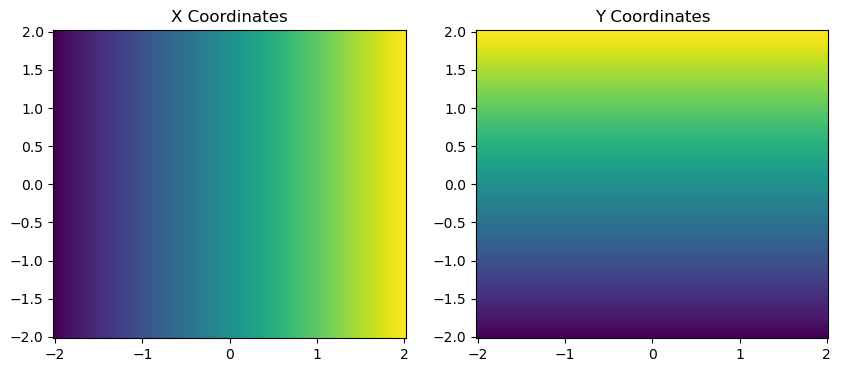

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].pcolormesh(x, y, x, shading='auto')
ax[0].set_title('X Coordinates')
ax[1].pcolormesh(x, y, y, shading='auto')
ax[1].set_title('Y Coordinates')
plt.show()

## 1.3 and 1.4

In [8]:
r = np.sqrt(x**2 + y**2)
phi = np.arctan2(y, x)

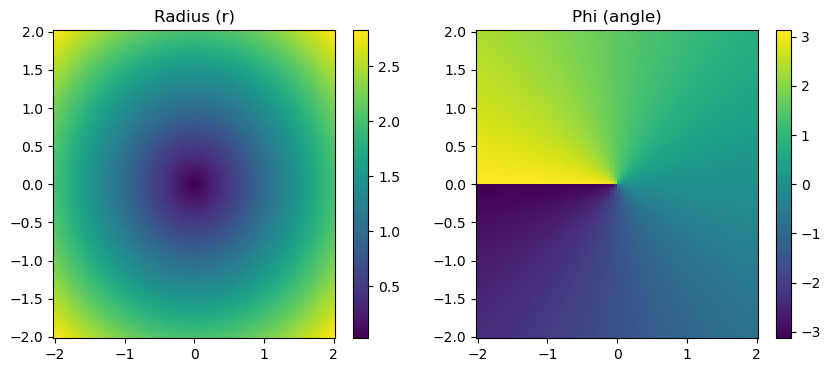

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
im1 = ax[0].pcolormesh(x, y, r, shading='auto')
ax[0].set_title('Radius (r)')
plt.colorbar(im1, ax=ax[0])
im2 = ax[1].pcolormesh(x, y, phi, shading='auto')
ax[1].set_title('Phi (angle)')
plt.colorbar(im2, ax=ax[1])
plt.show()

## 1.5 Caclulate the quanity 

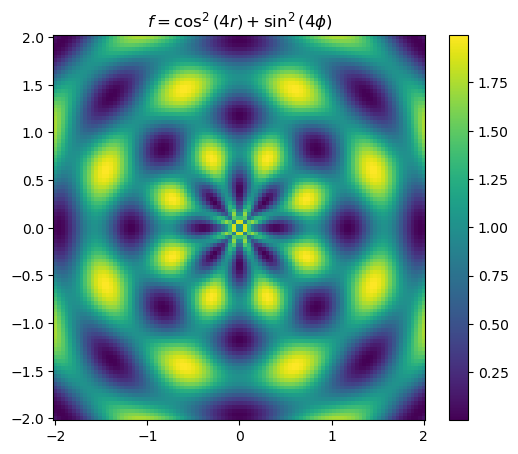

In [12]:
f = np.cos(4*r)**2 + np.sin(4*phi)**2
plt.figure(figsize=(6, 5))
plt.pcolormesh(x, y, f, shading='auto')
plt.title(r'$f = \cos^2(4r) + \sin^2(4\phi)$')
plt.colorbar()
plt.show()

# 2 Analyze ARGO Data

In [15]:
import pooch

In [16]:
url = "https://www.ldeo.columbia.edu/~danielmw/float_data.zip"
files = pooch.retrieve(url, processor=pooch.Unzip(), known_hash="2a703c720302c682f1662181d329c9f22f9f10e1539dc2d6082160a469165009")
files

['/home/eva2122/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy',
 '/home/eva2122/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy',
 '/home/eva2122/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy',
 '/home/eva2122/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy',
 '/home/eva2122/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy',
 '/home/eva2122/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy',
 '/home/eva2122/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy']

## 2.1 Load each data file as numpy array

In [18]:
T = np.load([f for f in files if 'T.npy' in f][0])
S = np.load([f for f in files if 'S.npy' in f][0])
P = np.load([f for f in files if 'P.npy' in f][0])
lat = np.load([f for f in files if 'lat.npy' in f][0])
lon = np.load([f for f in files if 'lon.npy' in f][0])
level = np.load([f for f in files if 'levels.npy' in f][0])

## 2.2 Examine shapes

In [19]:
print(f"Shapes - T: {T.shape}, Level: {level.shape}, Lon: {lon.shape}")

Shapes - T: (78, 75), Level: (78,), Lon: (75,)


## 2.3 and 2.6 Profile plots

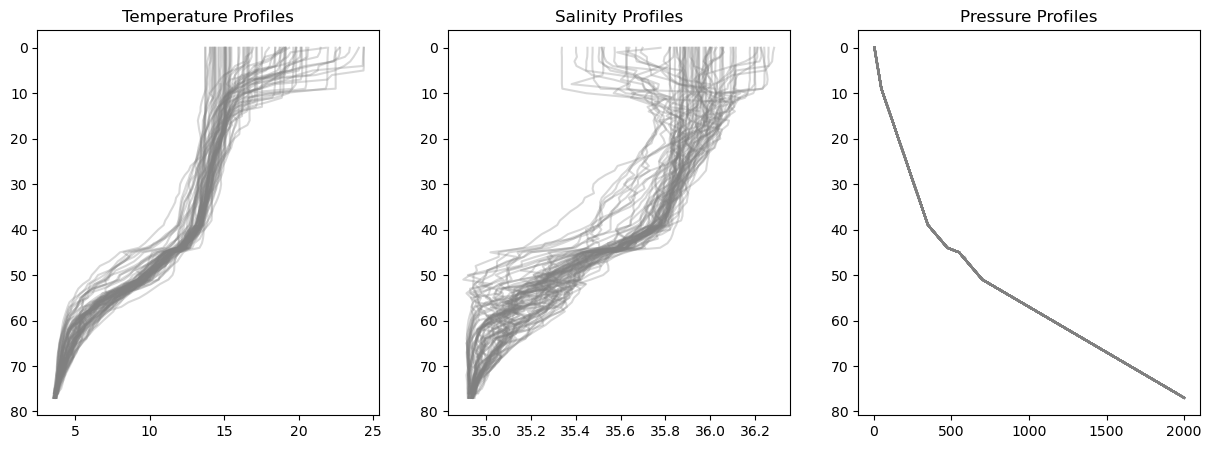

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(T, level, color='grey', alpha=0.3)
ax[0].set_title('Temperature Profiles')
ax[1].plot(S, level, color='grey', alpha=0.3)
ax[1].set_title('Salinity Profiles')
ax[2].plot(P, level, color='grey', alpha=0.3)
ax[2].set_title('Pressure Profiles')
for a in ax: a.invert_yaxis()
plt.show()

## 2.4, 2.5, 2.6

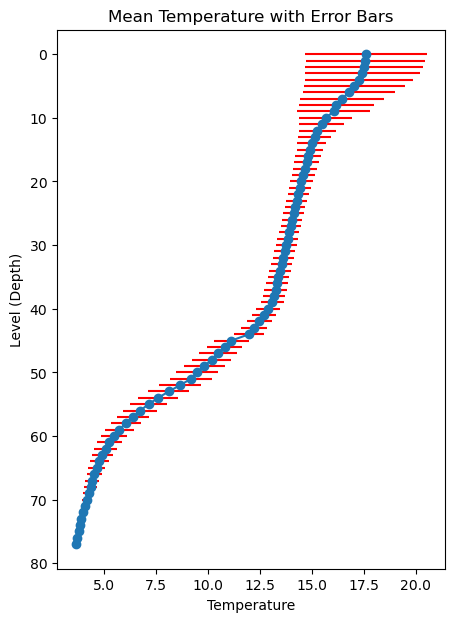

In [23]:
T_mean = np.nanmean(T, axis=1)
T_std = np.nanstd(T, axis=1)

plt.figure(figsize=(5, 7))
plt.errorbar(T_mean, level, xerr=T_std, fmt='-o', ecolor='red')
plt.gca().invert_yaxis()
plt.xlabel('Temperature')
plt.ylabel('Level (Depth)')
plt.title('Mean Temperature with Error Bars')
plt.show()

## 2.7 Create a scatter plot of the lon, lat pos of ARGO float

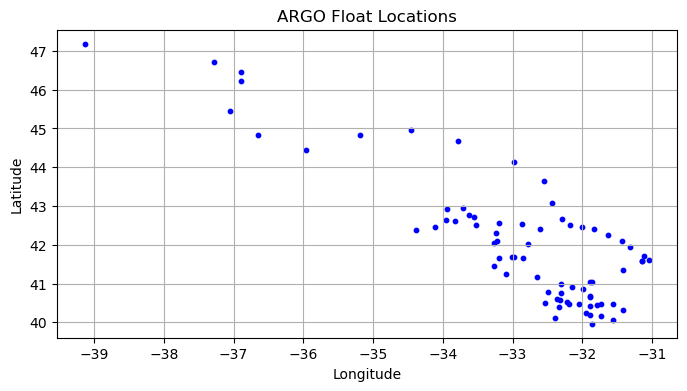

In [24]:
plt.figure(figsize=(8, 4))
plt.scatter(lon, lat, c='blue', s=10)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('ARGO Float Locations')
plt.grid(True)
plt.show()